In [1]:
import torch
import torchvision.datasets as dset
import torchvision.transforms as transforms
import kagglehub

# 1. Download the CelebA dataset via Kaggle
print("Downloading CelebA dataset via Kaggle...")
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")
print(f"Dataset successfully downloaded to: {path}")

# 2. Define hyperparameters for the dataset
image_size = 64
batch_size = 128

# 3. Create the preprocessing pipeline (resize, crop, tensor conversion, and normalization)
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)), # Normalizes to [-1, 1] for the Tanh activation
])

# 4. Load the dataset using ImageFolder
# ImageFolder will automatically find the 'img_align_celeba' subdirectory inside the downloaded path
dataset = dset.ImageFolder(root=path, transform=transform)

# 5. Create the DataLoader to handle batching and shuffling
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

# 6. Set the device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")
print(f"Total images loaded: {len(dataset)}")

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Dataset successfully downloaded to: /kaggle/input/celeba-dataset
Using device: cuda
Total images loaded: 202599


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt

In [5]:
class Generator(nn.Module):
    def __init__(self, nz=100, ngf=64, nc=3):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Input is Z, going into a convolution
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # State size: (ngf*8) x 4 x 4
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # State size: (ngf*4) x 8 x 8
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # State size: (ngf*2) x 16 x 16
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # State size: (ngf) x 32 x 32
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # Final state size: (nc) x 64 x 64
        )

    def forward(self, input):
        return self.main(input)

netG = Generator().to(device)

In [6]:
class Discriminator(nn.Module):
    def __init__(self, nc=3, ndf=64):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input is (nc) x 64 x 64
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: (ndf) x 32 x 32
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: (ndf*2) x 16 x 16
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: (ndf*4) x 8 x 8
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: (ndf*8) x 4 x 4
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

netD = Discriminator().to(device)

In [7]:
criterion = nn.BCELoss()

# Fixed noise to track structural generation progress over epochs
fixed_noise = torch.randn(64, 100, 1, 1, device=device)

real_label = 1.0
fake_label = 0.0

optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [8]:
num_epochs = 2
img_list = []
G_losses = []
D_losses = []
iters = 0

print("Starting Training Loop...")
for epoch in range(num_epochs):
    for i, data in enumerate(dataloader, 0):

        ############################
        # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
        ###########################
        netD.zero_grad()
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)

        # Forward pass real batch through D
        output = netD(real_cpu).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()

        # Generate fake batch
        noise = torch.randn(b_size, 100, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(fake_label)

        # Classify fake batch with D
        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()

        errD = errD_real + errD_fake
        optimizerD.step()

        ############################
        # (2) Update G network: maximize log(D(G(z)))
        ###########################
        netG.zero_grad()
        label.fill_(real_label) # Fake labels are real for generator cost
        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        optimizerG.step()

        # Save Losses for plotting
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        if iters % 500 == 0:
            print(f'[{epoch}/{num_epochs}][{i}/{len(dataloader)}] Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f}')

        iters += 1

Starting Training Loop...
[0/2][0/1583] Loss_D: 1.3396 Loss_G: 3.1569
[0/2][500/1583] Loss_D: 1.1423 Loss_G: 6.0935
[0/2][1000/1583] Loss_D: 1.1026 Loss_G: 3.2744
[0/2][1500/1583] Loss_D: 0.4532 Loss_G: 2.7892
[1/2][417/1583] Loss_D: 0.4518 Loss_G: 2.3662
[1/2][917/1583] Loss_D: 0.4088 Loss_G: 2.7725
[1/2][1417/1583] Loss_D: 1.1630 Loss_G: 4.8088


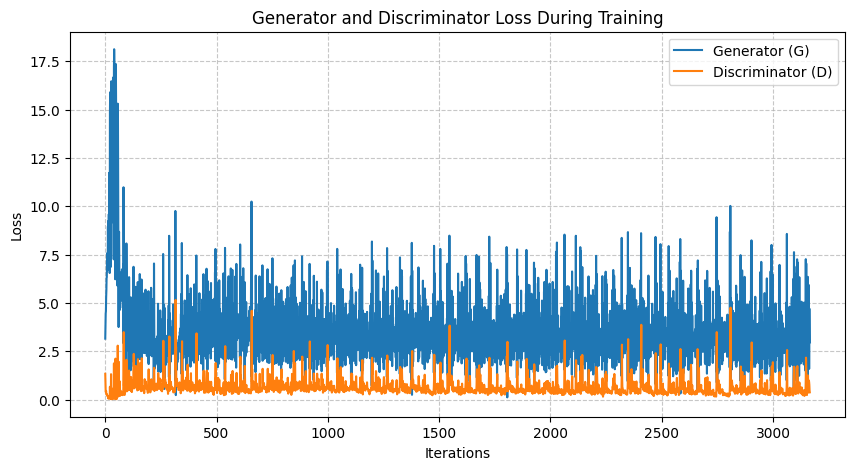

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="Generator (G)")
plt.plot(D_losses, label="Discriminator (D)")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Save the plot as an image for your LaTeX report
plt.savefig('loss_curves.png', bbox_inches='tight')
plt.show()

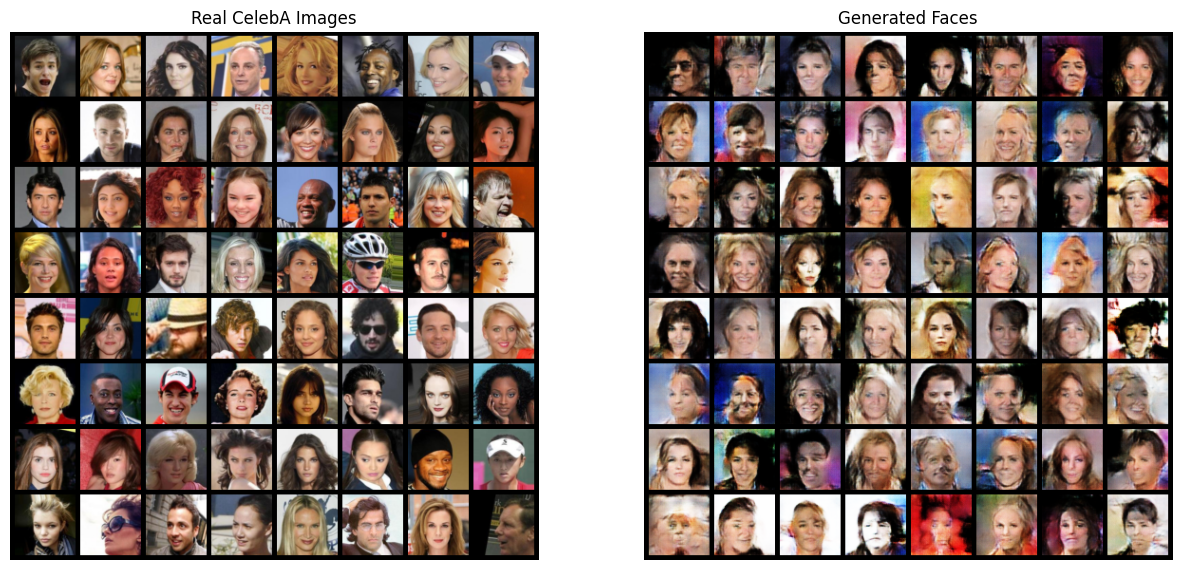

In [10]:
import torchvision.utils as vutils
import numpy as np

# 1. Grab a batch of real images from the dataloader
real_batch = next(iter(dataloader))

# 2. Plot the Real Images
plt.figure(figsize=(15, 15))
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Real CelebA Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=5, normalize=True).cpu(), (1, 2, 0)))

# 3. Plot the Fake (Generated) Images from the fixed noise
plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Generated Faces")
with torch.no_grad():
    fake_images = netG(fixed_noise).detach().cpu()
plt.imshow(np.transpose(vutils.make_grid(fake_images, padding=5, normalize=True), (1, 2, 0)))

# Save the comparison image
plt.savefig('real_vs_fake.png', bbox_inches='tight')
plt.show()

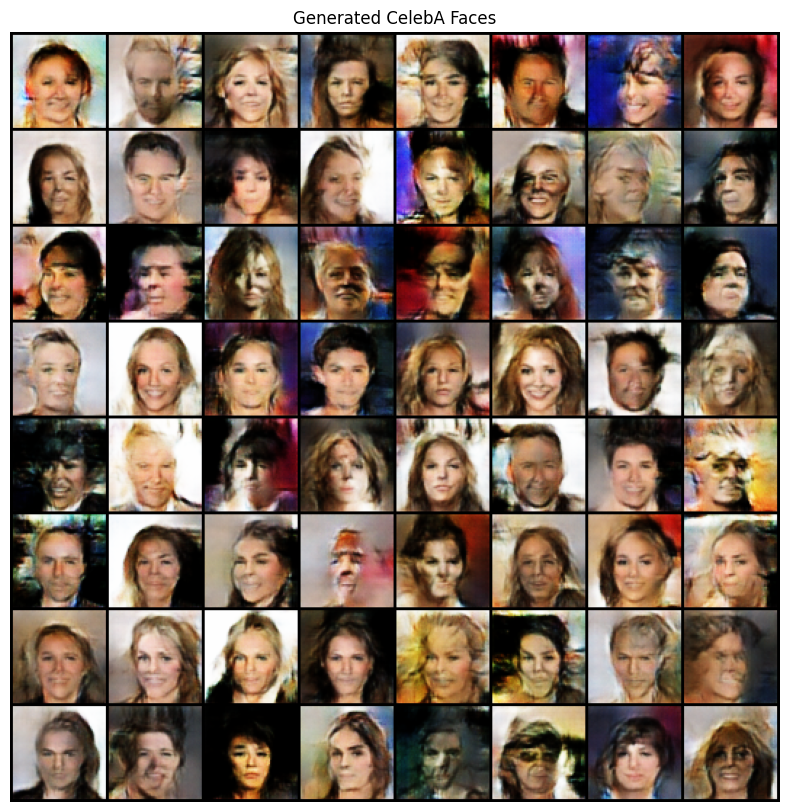

In [11]:
import torch
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np

# 1. Set the generator to evaluation mode
# This is a good practice, though DCGAN's BatchNorm behaves fine if left in train mode for this specific setup
netG.eval()

# 2. Define how many faces you want to generate
num_faces_to_generate = 64
latent_dim = 100

# 3. Create a batch of random noise vectors (z)
# Shape: (batch_size, latent_channels, height, width) -> (64, 100, 1, 1)
sample_noise = torch.randn(num_faces_to_generate, latent_dim, 1, 1, device=device)

# 4. Generate the faces!
# Use torch.no_grad() to save memory and compute, since we don't need gradients for inference
with torch.no_grad():
    generated_images = netG(sample_noise).detach().cpu()

# 5. Visualize the results using torchvision's make_grid
plt.figure(figsize=(10, 10))
plt.axis("off")
plt.title("Generated CelebA Faces")

# make_grid arranges the tensor into a grid format
# normalize=True automatically shifts the [-1, 1] Tanh output back to [0, 1] for matplotlib
grid = vutils.make_grid(generated_images, nrow=8, padding=2, normalize=True)

# PyTorch image tensors are (Channels, Height, Width)
# Matplotlib expects (Height, Width, Channels), so we use np.transpose
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.show()